## `Non Local Means`

Le débruitage Non-Local Means (NLM) est une méthode de débruitage par patchs qui exploite la redondance des motifs dans l’image, même à grande distance.

__`Idée de base`__
- une image naturelle contient beaucoup de motifs qui se répètent (textures, briques, feuillage, etc.),
- pas seulement localement mais partout dans l’image.
- pour débruiter un pixel $i$, NLM ne se limite pas à un petit voisinage local,
- il cherche, dans une zone plus large ou toute l’image, des patchs similaires au patch centré en $i$.
- la valeur débruitée de $i$ est une moyenne pondérée des valeurs d’autres pixels $j$, 
- où le poids est d’autant plus grand que le patch autour de $j$ ressemble à celui de $i$.

__`Formule typique`__ : $\large \hat{u}(i) = \sum_{j} w(i,j)\, v(j), \qquad \sum_{j} w(i,j) = 1 $
 - où $v$ est l’image bruitée et $w(i,j)$ dépend de la distance entre les patchs autour de $i$ et $j$.
 
__`Calcul des poids`__
- On considère un patch $P_i$ autour du pixel $i$ (par ex. taille $(2w+1)×(2w+1)$).
- Pour chaque pixel $j$ dans une fenêtre de recherche autour de $i$, on compare $P_i$ et $P_j$
- ​Le poids est souvent de la forme: 
$$\omega(i,j)\alpha*\exp \Bigl( \large \frac{||P_i − P_j||_2^2}{−h_2} \Bigr)$$

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

#from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

### `Patches in Images`
Cette partie est dédiée à l'étude des structures de patch dans les images 
Dimension de l'image $N = n \times n$.

In [3]:
n = 128

- Nous chargeons un image bruitée $f_0\in \mathcal{R}^N$.
- En Python l’indexation d’une image se fait en ligne, colonne = y, x.
- Les coordonnées x,y représente le centre du patch que l'on extrait dans l’image f.
  - y-n:y+n coupe verticalement (lignes).
  - x-n:x+n coupe horizontalement (colonnes).

In [80]:
print(np.linspace(1,10)[-1])

10.0


In [84]:
from skimage.transform import rescale, resize
from skimage.util import crop

path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/lena.png'
f = load_image(name,n) 
print(f.shape)
x, y = 100, 200 
f0 = f[y-n:y+n, x-n:x+n]
print(f"f0[{y-n}:{y+n},{x-n}:{x+n}], patch shape {f0.shape}")
# équivalent conceptuel d'un rescale des valeurs dans [0,1]
f0 = f0.astype(np.float32)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-8)

(128, 128)
f0[72:328,-28:228], patch shape (56, 28)


Affichage $f_0$ $f$.

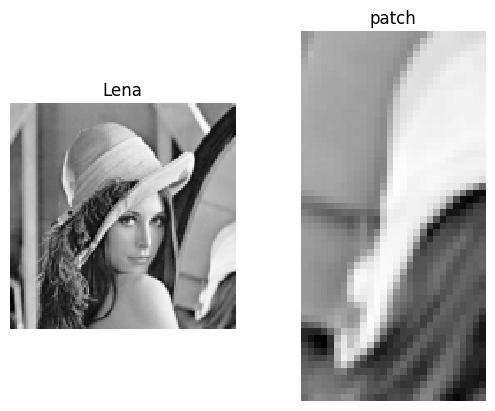

In [85]:
imageplot(clamp(f),'Lena',[1,2,1])
imageplot(clamp(f0),'patch',[1,2,2])

Ajouter un bruit gaussien additif $\epsilon$, tel que l'image bruitée $f=f_0+\epsilon$ où $\epsilon \approx \mathcal{N}(0,\sigma^2\text{Id}_N)$.
$\epsilon$ est un vecteur aléatoire gaussien de dimension $N$ (où $N$ est le nombre de pixels), de   
- moyenne nulle (centre en 0),  
- de matrice de covariance $\mathcal{N}(0,\sigma^2\text{Id}_N)$
Chaque pixel de bruit suit une loi normale $\mathcal{N}(0,\sigma^2)$, les composantes sont indépendantes entre elles.


128


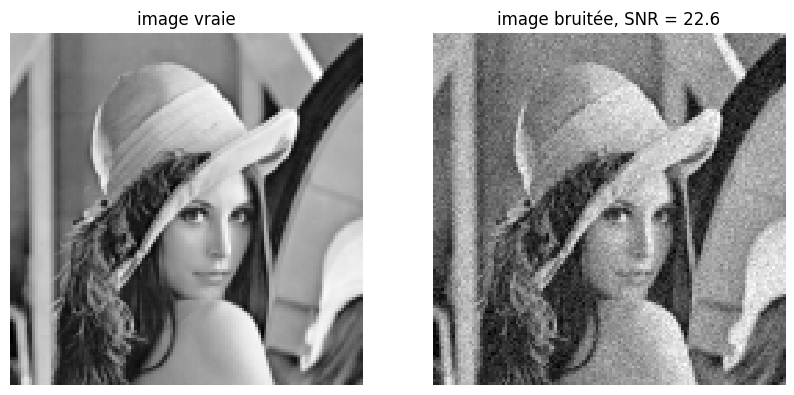

In [86]:
sigma = .04
img = f + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 10))
print(img.shape[0])
imageplot(clamp(f),'image vraie',[1,2,1])
imageplot(clamp(img),f"image bruitée, SNR = {snr(f,img):.3g}" , [1,2,2])

Nous construisons les coordonnées des patchs $7×7$ car $w=3$, donc $w_1 = 2 * w + 1 = 7$ autour de chaque pixel, en gérant les bords par réflexion. 
Nous construisons des matrices de tailles $(n,n,w_1,w_1)$ pour indexer les position de X et Y du pixel à extraire. 
- Localisation des pixels.
- Décalage (offsets)
- Localisation des pixels à extraire

In [29]:
w = 3
w1 = 2*w + 1

__Pour $w=3$, se réfère à un patch carré centré sur un pixel__.
- $w$ est la demi‑largeur, 
- $w$ demi‑hauteur du patch, 
- la distance en pixels entre le centre et chaque bord.
__La largeur totale du patch est $w1=2w+1$__
- Avec w=3, on a $w_1=2×3+1=7$.
`Concrètement, si le centre est au (x,y), le patch couvre` :
- horizontalement : $(x−3)$ , $(x−2)$ , $(x−1)$ , `(x)` , $(x+1)$ , $(x+2)$ , $(x+3)$ → 7 colonnes,
- verticalement   : $(y−3)$ , $(y−2)$ , $(y−1)$ , `(y)` , $(y+1)$ , $(y+2)$ , $(y+3)$ → 7 lignes.
Donc le patch est un carré de taille $7×7$ centré sur ce pixel.

In [149]:
import numpy as np
# Paramètres et grilles de base
Y, X = np.meshgrid(np.arange(n), np.arange(n))
print(np.array(X).shape)
# Décalages dans le patch on crée les offsets du patch :
dY, dX = np.meshgrid(np.arange(-w,w+1),np.arange(-w,w+1))
print(np.array(dY).shape)

(128, 128)
(7, 7)


In [150]:
dX = dX[None, None, :, :] 
print(np.array(dX).shape)     
dY = dY[None, None, :, :]
X = X[:, :, None, None] + dX
print(np.array(X).shape)
Y = Y[:, :, None, None] + dY

(1, 1, 7, 7)
(128, 128, 7, 7)


__`Traiter les conditions limites des bors par réflexion`__ 
- pour traiter les bords de l’image (quand un patch ou un filtre « sort » en dehors), 
- on prolonge l’image, les pixels en dehors sont pris comme un miroir de ceux à l’intérieur.
__Pour une réflexion symétrique__
En 0‑based sur [0, n-1], padding miroir plusieurs conventions possibles, schéma typique 1D est :
 - Pour un index brut k, le ramener dans [0, n-1] en appliquant un modulo sur une période 2*(n-1) 
 - puis une réflexion autour des bords.

In [151]:
def reflect_indices(idx, n):
    # idx : tableau (X ou Y), n : taille (128 pour une image 128x128)
    if n == 1:
        return np.zeros_like(idx)
    period = 2*(n-1)
    idx_mod = idx % period
    mask = idx_mod >= n
    idx_mod[mask] = period - idx_mod[mask]
    return idx_mod

Operateur d'extracteur de patch
1. Vectorisation de l’image

In [215]:
# img : image 2D (n, n)
n = img.shape[0]

print(f"img.shape:{img.shape}\nimg:{img[0,:1:,:1]}")
f = img.T.reshape(-1)   # ou img.reshape(-1, order='F')
print(f"f.shape : {f.shape} , {f[:3]}")

img.shape:(128, 128, 7, 7)
img:[[[0.5539815  0.63215491 0.57796827 0.64568179 0.64321583 0.70438042
   0.57796827]]]
f.shape : (802816,) , [0.5539815  0.65989566 0.68723799]


Pour une image vectorisée colonne par colonne, l’indice linéaire d’un pixel (x,y) (où x = colonne, y = ligne, 0-based) est :

In [180]:
# X, Y : indices 0-based de taille (n, n, w1, w1)
# ind_lin = X + Y * n
X_ref = reflect_indices(X, n)
Y_ref = reflect_indices(Y, n)
ind = X_ref + Y_ref * n # même shape que X, Y

def patch(f_vec):
    return f_vec[ind]   # renvoie les patchs

- Définir la matrice du patch $P$ de taille $(n,n,w_1,w_1)$ 
- Chaque $|P(i,j,:,:)|$ représente un patch $(w_1,w_1)$ extrait autour du pixel $(i,j)$ dans l'image.

Afficher différents exemples de patchs

La dimension de P: (128, 128, 7, 7)
décrit un tenseur 4D qui code un patch 7×7
autour de chaque pixel d’une image 128×128


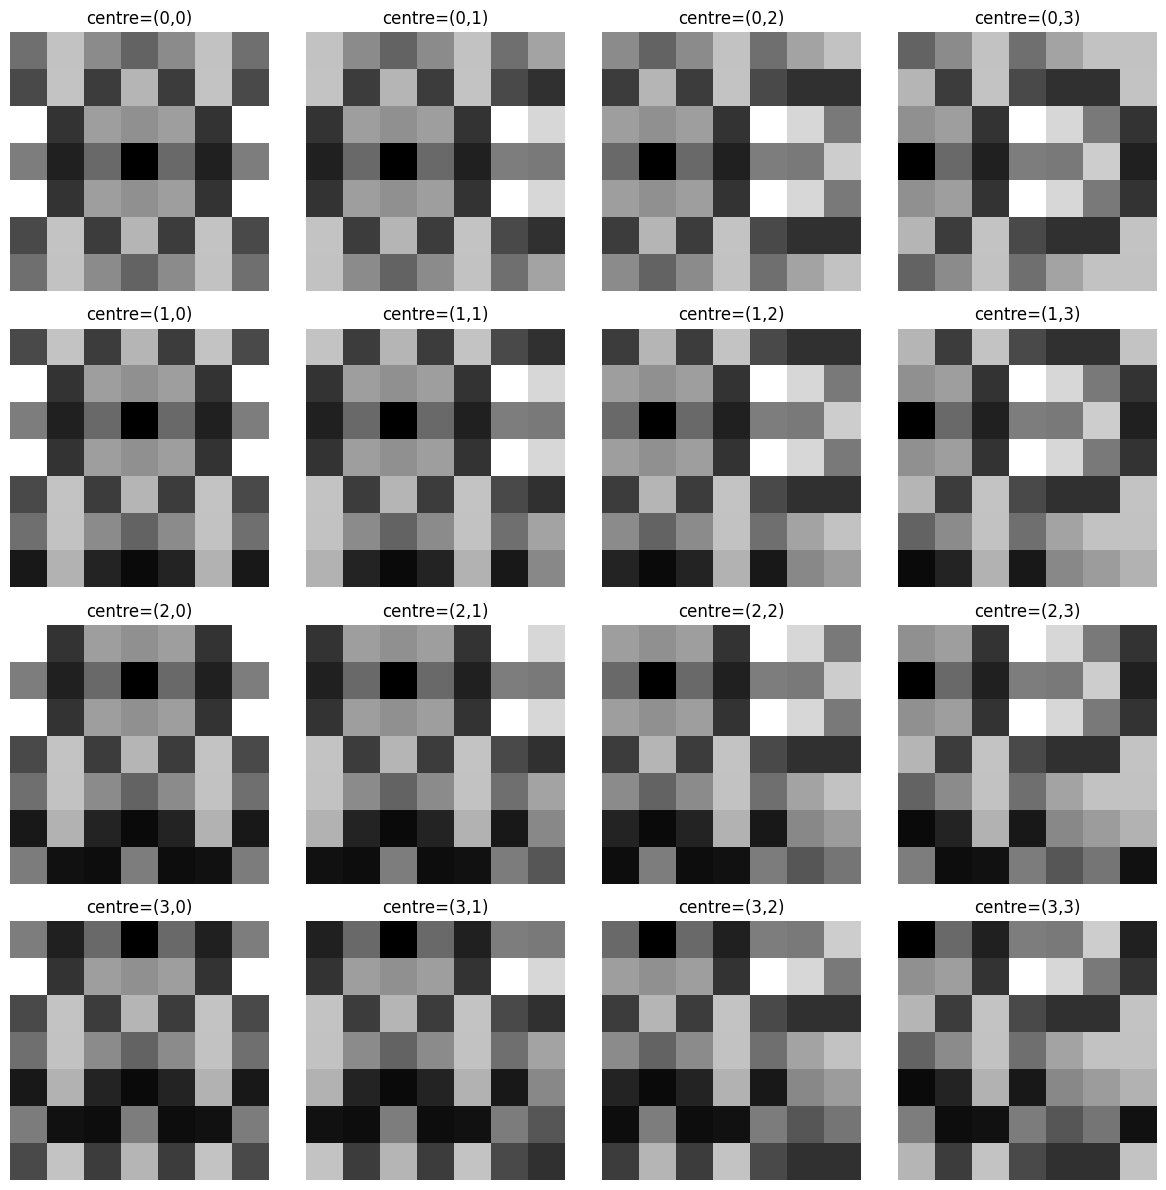

In [248]:
import numpy as np
import matplotlib.pyplot as plt

# 5. On calcule tous les patchs une fois pour toutes
P = patch(f)                  # P est un ndarray, shape (n, n, w1, w1)
print(f"La dimension de P: {P.shape}\ndécrit un tenseur 4D qui code un patch 7×7\nautour de chaque pixel d’une image 128×128")
# 6. On affiche quelques patchs
fig, axes = plt.subplots(4, 4, figsize=(12,12))

coords = [
          (0, 0),(0, 1), (0, 2), (0, 3),
          (1, 0),(1, 1), (1, 2), (1, 3),
          (2, 0),(2, 1), (2, 2), (2, 3),
          (3, 0),(3, 1), (3, 2), (3, 3),
          ]  # centres (y, x)

for i, (y, x) in enumerate(coords):
    ax = axes[i // 4, i % 4]
    one_patch = P[y, x]       # one_patch est 2D: shape (3,3)
    ax.imshow(one_patch, cmap='gray')
    ax.set_title(f"centre=({y},{x})")
    ax.axis('off')

plt.tight_layout()
plt.show()

#### __`Réduction de dimension avec l’ACP (Analyse en Composantes Principales)`__
Comme les algorithmes de type NL-means nécessitent le calcul d’un grand nombre de distances entre les patchs, il est avantageux de réduire la dimension du patch tout en conservant le maximum d’informations possible.

In [209]:
# Dimension cible du patch
d = 25

`Une réduction de dimension est obtenue par l'Analyse des Composantes Principales (PCA)`:
- on projette les données sur un petit nombre de direction principales de la matrice de covariance des patchs. 
- on réorganise la matrice de patchs en un tableau de dimension $|(w1*w1,n*n)|$ 
- de sorte que chaque colonne $|P(:,i)|$ soit un vecteur $|P(:,i)|$ représentant un patch. 

In [219]:
resh = lambda P:np.reshape(P,(n*n, w1*w1))

__`Un opérateur pour retirer la moyenne des patchs pour chaque patch`__ 
- L’idée est de centrer chaque patch, comme on le fait pour les données avant une ACP.
- Supposons que le tableau Q ait une colonne par patch, et que chaque colonne soit un vecteur $w_1×w_1$ « aplati ».
Pour une colonne $Q(:,i)$ (un patch), on peut calculer sa moyenne scalaire 
- $m_i = mean(Q(:,i))$ 
et construire un nouveau vecteur 
- $Q_{centered}(:,i) = Q(:,i) − m_i$
- Autrement dit, on soustrait la même valeur $m_i$ à tous les pixels du patch $i$. 
- Le patch résultant a alors une moyenne nulle (ou très proche, numériquement)

In [226]:
# repmat(A, 2, 3) → np.tile(A, (2, 3))
# remove_mean = lambda Q:Q - repmat(mean(Q), [w1*w1 1])
remove_mean = lambda Q:Q - np.mean(Q,axis=0, keepdims=True)

Calculer la moyenne et la covariance du nuage de point représentant les patchs.
 - resh(P) met d’abord tous les patchs dans une grande matrice 2D, puis 
 - remove_mean les centre, et enfin 
 - C = P1*P1 construit la matrice de covariance (à une constante près).

C calcule alors une matrice $w1*w1 × w1*w1$ qui est proportionnelle à la matrice de covariance des patches (on ne divise pas par n*n, mais pour l’ACP ça ne change pas les vecteurs propres).

In [227]:
np.mean(P,axis=0, keepdims=True)
print(f"P.shape : {P.shape}")
T = resh(P)
print(f"T.shape : {T.shape}")
P1 = remove_mean(T)
C = P1 * P1

P.shape : (128, 128, 7, 7)
T.shape : (16384, 49)


Extract the eigenvectors, sorted by decreasing amplitude

In [ ]:
[V, D] = eig(C); D = diag(D)
[D, I] = sort(D, 'descend'); V = V(: , I)

Display the decaying amplitude of the eigenvalues.

In [ ]:
plot(D); axis('tight')

Display the leading eigenvectors - they look like Fourier modes.

In [ ]:
for i in 1: 16:
    imageplot(reshape(V(: , i), [w1 w1]), '', 4, 4, i)

Patch dimensionality reduction operator.

In [ ]:
iresh = lambda Q: reshape(Q', [n n d])
descriptor = lambda f: iresh(V(: , 1: d)' * remove_mean(resh(P)))

Each |H(i,j,:)| is a $d$-dimensional descriptor
of a patch.

In [ ]:
H = descriptor(f)

Non-local Filter
----------------
NL-means applies, to each pixel location, an adaptive averaging kernel
that is computed from patch distances.


We denote $H_{i} \in \RR^d$ the descriptor at pixel $i$.
We define the distance matrix
$$ D_{i,j} = \frac{1}{w_1^2}\norm{H_i-H_j}^2. $$



Operator to compute the distances $(D_{i,j})_j$ between the patch around $i=(i_1,i_2)$
and all the other ones.

In [ ]:
distance = lambda i: sum((H - repmat(H(i(1), i(2), : ), [n n 1])).^2, 3)/ (w1*w1)

The non-local mean filter compute a denoised image $\tilde f$ as
$$ \tilde f_i = \sum_j K_{i,j} f_j $$
where the weights $K$ are computed as
$$ K_{i,j} = \frac{ \tilde K_{i,j} }{ \sum_{j'} \tilde K_{i,j'} }
      \qandq
   \tilde K_{i,j} = e^{-\frac{D_{i,j}}{2\tau^2}} . $$



The width $\tau$ of the Gaussian is very important and should be adapted to match
the noise level.



Compute and normalize the weight.

In [ ]:
normalize = lambda K: K/ sum(K(: ))
kernel = lambda i, tau: normalize(exp(-distance(i)/ (2*tau^2)))

Compute a typical example of kernel for some pixel position $(x,y)$.

In [ ]:
tau = .05
i = [83 72]
D = distance(i)
K = kernel(i, tau)

Display the squared distance and the kernel.

In [ ]:
imageplot(D, 'D', 1, 2, 1)
imageplot(K, 'K', 1, 2, 2)

Localizing the Non-local Means
------------------------------
We set a "locality constant" $q$ that set the maximum distance between
patches to compare. This allows to speed up computation, and makes
NL-means type methods semi-global (to avoid searching in all the image).

In [ ]:
q = 14

Using this locality constant, we compute the distance between patches
only within a window.
Once again, one should be careful about boundary conditions.

In [ ]:
selection = lambda i: {clamp(i(1)-q: i(1) + q, 1, n), clamp(i(2)-q: i(2) + q, 1, n)}

Compute distance and kernel only within the window.

In [ ]:
distance = lambda i, sel: sum((H(sel{1}, sel{2}, : ) - repmat(H(i(1), i(2), : ), ...
        [length(sel{1}) length(sel{2}) 1])).^2, 3)/ (w1*w1)
distance = lambda i: distance(i, selection(i))
kernel = lambda i, tau: normalize(exp(-distance(i)/ (2*tau^2)))

Compute a typical example of kernel for some pixel position $(x,y)$.

In [ ]:
D = distance(i)
K = kernel(i, tau)

Display the squared distance and the kernel.

In [ ]:
imageplot(D, 'D', 1, 2, 1)
imageplot(K, 'K', 1, 2, 2)

The NL-filtered value at pixel $(x,y)$ is obtained by averaging the values
of $f$ with the weight $K$.

In [ ]:
NLval = lambda K, sel: sum(sum(K.*f(sel{1}, sel{2})))
NLval = lambda i, tau: NLval(kernel(i, tau), selection(i))

We apply the filter to each pixel location
to perform the NL-means algorithm.

In [ ]:
[Y, X] = meshgrid(1: n, 1: n)
NLmeans = lambda tau: arrayfun(lambda i1, i2: NLval([i1 i2], tau), X, Y)

Display the result for some value of $\tau$.

In [ ]:
tau = .03

imageplot(NLmeans(tau))

__Exercise 1__

Compute the denoising result for several values of $\tau$ in order to
determine the optimal denoising that minimizes $\norm{\tilde f - f_0}$.

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Display the best result.

In [ ]:
imageplot(clamp(fNL))

__Exercise 2__

Explore the influence of the $q$ and $w$ parameters.

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

Bibliography
------------
<html><a name="biblio"></a></html>


* [BuaCoMoA05] Buades, B. Coll, J.f Morel, [A review of image denoising algorithms, with a new one][1], SIAM Multiscale Modeling and Simulation, Vol 4 (2), pp: 490-530, 2005.

[1]:http://dx.doi.org/10.1137/040616024